# Text Classification
- **Overview**: For this assignment, we’ll be building a text classifier. The goal of our text classifer will be to distinguish between words that are simple and words that are complex. Example simple words are `heard`, `sat`, and `town`, and example complex words are `abdicate`, `detained`, and `vintners`. Distinguishing between simple and complex words is the first step in a larger NLP task called text simplification, which aims to replace complex words with simpler synonyms. Text simplification is potentially useful for re-writing texts so that they can be more easily understood by younger readers, people learning English as a second language, or people with learning disabilities.

- **Learning goals**:
    - Understand an important class of NLP evaluation methods (precision, recall and F1), and implement them yourself.
    - Employ common experimental design practices in NLP. Split the annotated data into training/development/test sets, implement simple baselines to determine how difficult the task is, and experiment with a range of features and models.
    - Get an introduction to `sklearn`, an excellent machine learning Python package.

- **Data**: We will provide you with training and development data that has been manually labeled. We will also give you a test set without labels. You will build a classifier to predict the labels on our test set. You can upload your classifier’s predictions to Gradescope. We will score its predictions and maintain a leaderboard showing whose classifier has the best performance.

---
- **Delieverables:** This assignment has several deliverables:
  - Code (this notebook) *(Automatic Graded)*
    - rename to `homework2.ipynb` and `homework2.py`.
  - Write Up (in a separate **writeup.pdf**) *(Manually Graded)*
    - Answers to all questions labeled as `Answer #.#` in a file named `writeup.pdf`
  - Leaderboard: Section 4 *(Automatic Graded on GradeScope)*
    - Your best model’s output for the test set using only the provided training and development data (`test_labels.txt`)
    - (Optional) your best model’s output for the test set, using any data that you want. (`test_labels.txt`)

- **Grading**: We will use the auto-grading system called `PennGrader`. To complete the homework assignment, you should implement anything marked with `#TODO` or `##YOUR CODE HERE` and run the cell with `#PennGrader` note.

## Recommended Readings
- [Naive Bayes Classification and Sentiment](https://web.stanford.edu/~jurafsky/slp3/4.pdf) Dan Jurafsky and James H. Martin. Speech and Language Processing (3rd edition draft).
- [Logistic Regression](https://web.stanford.edu/~jurafsky/slp3/5.pdf) Dan Jurafsky and James H. Martin. Speech and Language Processing (3rd edition draft) .
- [Problems in Current Text Simplification Research: New Data Can Help](http://www.cis.upenn.edu/~ccb/publications/new-data-for-text-simplification.pdf) Wei Xu, Chris Callison-Burch, and Courtney Napoles. TACL 2015.
- [Comparison of Techniques to Automatically Identify Complex Words](http://aclweb.org/anthology/P/P13/P13-3015.pdf) Matthew Shardlow. ACL 2013.
- [SemEval 2016 Task 11: Complex Word Identification](https://www.researchgate.net/profile/Gustavo_Paetzold/publication/305334627_SemEval_2016_Task_11_Complex_Word_Identification/links/57bab70a08ae14f440bd9722/SemEval-2016-Task-11-Complex-Word-Identification.pdf) Gustavo Paetzold and Lucia Specia. ACL 2016.

## Setup: Dataset / Packages
- **Run the following cells without changing anything!**
- [Loading dataset from huggingface](https://huggingface.co/docs/datasets/v1.8.0/loading_datasets.html#from-local-files)

In [7]:
from collections import defaultdict
import gzip

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import numpy as np
from tqdm import tqdm
from dill.source import getsource

In [10]:
train_file = "complex_words_training.txt"
dev_file = "complex_words_development.txt"
test_file = "complex_words_test_unlabeled.txt"
mini_test_file = 'complex_words_test_mini.txt'

In [11]:
########## DO NOT CHANGE ##########
## Loads in the words and labels of one of the datasets
def load_labeled_file(data_file):
    words = []
    labels = []
    with open(data_file, 'rt', encoding="utf8") as f:
        i = 0
        for line in f:
            if i > 0:
                line_split = line[:-1].split("\t")
                words.append(line_split[0].lower())
                labels.append(int(line_split[1]))
            i += 1
    return words, labels

def load_unlabeled_file(data_file):
    words = []
    # labels = []
    with open(data_file, 'rt', encoding="utf8") as f:
        words = [line.strip() for line in f.readlines() if len(line.strip()) > 0]
    return words

def load_test_file(data_file):
    words = []
    with open(data_file, 'rt', encoding="utf8") as f:
        next(f) # skip first line (header)
        words = [line.strip().split('\t')[0] for line in f.readlines() if len(line.strip()) > 0]
    return words

## Loads Google NGram counts
def load_ngram_counts(ngram_counts_file = 'ngram_counts.txt.gz'):
    counts = defaultdict(int)
    with gzip.open(ngram_counts_file, 'rt') as f:
        for line in f:
            token, count = line.strip().split('\t')
            if token[0].islower():
                counts[token] = int(count)
    return counts

ngram_counts = load_ngram_counts()

### About the data
- `train_data`, `dev_data`: these are words with labels, provided for you to train and evaluate your models.
- `mini_test_words`: this is a subset (50) of the unseen test dataset, we will provide test the **basic functionality** of your models based on the performance on this mini testset (PennGrader tests). **This would only be a basic sanity check of your implementation. The final grade would be based on the PennGrader Grades and manual grading on your implementation**
- `test_words`: this is the full, unlabelled test set. You are expected to submit the prediction of these words at the end of the assignment.

In [12]:
########## DO NOT CHANGE ##########
train_data = load_labeled_file(train_file)
dev_data = load_labeled_file(dev_file)
mini_test_words = load_unlabeled_file(mini_test_file)
test_words = load_test_file(test_file)

# you can take a look at this mini-dev data by uncommenting this line
dev_words, dev_labels = dev_data
dev_words[:5] # some examples of this dev dataset

['hammer', 'renewable', 'showings', 'academy', 'continues']

In [13]:
mini_test_words[:5]

['threads', 'reinforce', 'letters', 'pioneered', 'closer']

# Section 1. Implement the Evaluation Metrics
- You might find this [Wikipedia Page](https://en.wikipedia.org/wiki/Precision_and_recall) useful.
- **Problem 1.1** Predicion, Recall, F1 Score

In [14]:
def get_precision(y_true, y_pred):
    true_pos = sum(yt == yp == 1 for yt, yp in zip(y_true, y_pred))
    predicted_pos = sum(yp == 1 for yp in y_pred)
    return true_pos / predicted_pos if predicted_pos > 0 else 0.0

def get_recall(y_true, y_pred):
    true_pos = sum(yt == yp == 1 for yt, yp in zip(y_true, y_pred))
    actual_pos = sum(yt == 1 for yt in y_true)
    return true_pos / actual_pos if actual_pos > 0 else 0.0

def get_fscore(y_true, y_pred):
    precision = get_precision(y_true, y_pred)
    recall = get_recall(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


# Section 2. Baselines

## 2.1 Implement a majority class baseline
You should start by implementing simple baselines as classifiers. Your first baseline is a **majority class baseline** which is one of the most simple classifier. You should complete the function `all_complex(words)`, which takes in a list of words, and returns out the predictions.


- **Problem 2.1:** Implement `all_complex()` that always predicts the majority class of the data (i.e. predicting every word as complex)

In [16]:
## Labels every word complex
def all_complex(words):
    y_pred = [1 for _ in words]
    return y_pred

- **Answer 2.1:** Please report the precision, recall, and f-score on both the training data and the development data.
    - Training **[writeup.pdf]**
    - Development **[writeup.pdf]**

In [17]:
dev_words, dev_labels = dev_data
y_pred = all_complex(dev_words)
precision = get_precision(dev_labels, y_pred)
recall = get_recall(dev_labels, y_pred)
fscore = get_fscore(dev_labels, y_pred)

print("Development Results:")
print(f" Precision: {precision:.4f}\n Recall: {recall:.4f}\n F1: {fscore:.4f}")

train_words, train_labels = train_data
t_pred = all_complex(train_words)
tprecision = get_precision(train_labels, t_pred)
trecall = get_recall(train_labels, t_pred)
tfscore = get_fscore(train_labels, t_pred)

print("\n\nTraining Results:")
print(f" Precision: {tprecision:.4f}\n Recall: {trecall:.4f}\n F1: {tfscore:.4f}")


Development Results:
 Precision: 0.4180
 Recall: 1.0000
 F1: 0.5896


Training Results:
 Precision: 0.4328
 Recall: 1.0000
 F1: 0.6041


## 2.2 Word length baseline
For our next baseline, we will use a slightly complex baseline, the length of each word to predict its complexity.

For the word length baseline, you should try setting various thresholds for word length to classify them as simple or otherwise. For example, you might set a threshold of 9, meaning that any words with less than 9 characters will be labeled simple, and any words with 9 characters or more will be labeled complex. Once you find the best threshold using the training data, use this same threshold for the development data as well.

You will be filling in the function `word_length_threshold(train_data, dev_data)`. This function takes in both the training and development datasets, finds the best threshold on word length and returns out the predictions on development data for your best threshold.

Usually, Precision and Recall are inversely related and while building binary-classification systems we try to find a good balance between them (by maximizing f-score, for example). It is often useful to plot the Precision-Recall curve for various settings of the classifier to gauge its performance and compare it to other classifiers. For example, for this baseline, a Precision-Recall curve can be plotted by plotting the Precision (on the y-axis) and Recall (on the X-axis) for different values of word-length threshold.

- **Problem 2.2:** Implement `word_length_threshold()` that finds the best word length threshold and makes predictions on the development (or testing) data.

In [19]:
### 2.2: Word length thresholding
## Makes feature matrix for word_length_threshold
def length_threshold_feature(words, threshold):
    return [1 if len(word) >= threshold else 0 for word in words]

## Finds the best length threshold by f-score, and uses this threshold to
## classify the training and development set
def word_length_threshold(train_data, dev_words):
    twords, tlabels = train_data
    best_threshold = None
    best_fscore = -1
    best_pred = []

    for threshold in range(1, 21):
        y_pred = length_threshold_feature(twords, threshold)
        fscore = get_fscore(tlabels, y_pred)
        if fscore > best_fscore:
            best_fscore = fscore
            best_threshold = threshold

    dev_pred = length_threshold_feature(dev_words, best_threshold)

    return dev_pred

- **Answer 2.2:** Please report the precision, recall, and f-score on both the training data and the development data.
    - Training **[writeup.pdf]**
    - Development **[writeup.pdf]**
    - Range of thresholds tested using the training data **[writeup.pdf]**
    - Best threshold **[writeup.pdf]**
    - Precision-recall Curve for training data **[writeup.pdf]**
        - For plotting, [matplotlib](https://matplotlib.org/) is a useful python library

In [20]:
dev_words, dev_labels = dev_data
y_pred = word_length_threshold(train_data, dev_words)
dprecision = get_precision(dev_labels, y_pred)
drecall = get_recall(dev_labels, y_pred)
dfscore = get_fscore(dev_labels, y_pred)
dfscore

0.7125984251968505

Range of thresholds tested: [1-21]
Best threshold: 7

Train Set:
Precision: 0.6007
Recall:    0.8440
F-score:   0.7019

Dev Set:
Precision: 0.6054
Recall:    0.8660
F-score:   0.7126


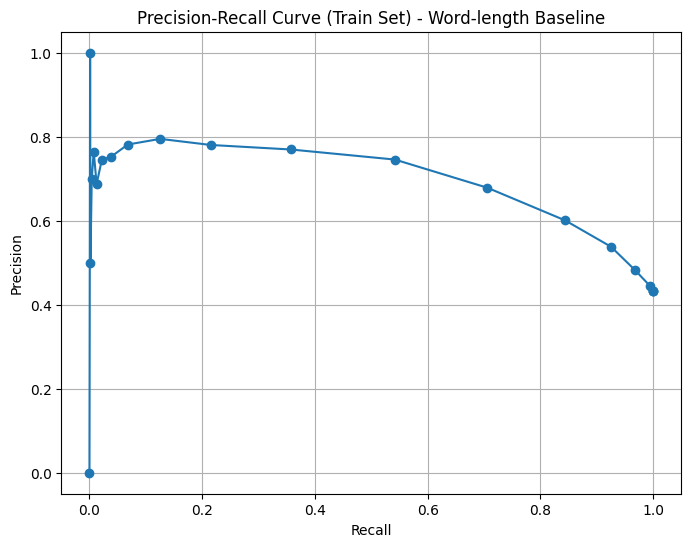

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Load training and dev data
train_words, train_labels = load_labeled_file(train_file)
dev_words, dev_labels = load_labeled_file(dev_file)

# Classify based on word length threshold
def length_threshold_predict(words, threshold):
    return [1 if len(word) >= threshold else 0 for word in words]

# Evaluate across thresholds
thresholds = list(range(1, 22))
train_precisions, train_recalls, train_f1s = [], [], []
best_threshold, best_f1 = None, -1

for t in thresholds:
    y_pred_train = length_threshold_predict(train_words, t)
    p = precision_score(train_labels, y_pred_train, zero_division=0)
    r = recall_score(train_labels, y_pred_train, zero_division=0)
    f = f1_score(train_labels, y_pred_train, zero_division=0)

    train_precisions.append(p)
    train_recalls.append(r)
    train_f1s.append(f)

    if f > best_f1:
        best_f1 = f
        best_threshold = t

# Evaluate best threshold on dev set
y_pred_dev = length_threshold_predict(dev_words, best_threshold)
dev_precision = precision_score(dev_labels, y_pred_dev, zero_division=0)
dev_recall = recall_score(dev_labels, y_pred_dev, zero_division=0)
dev_f1 = f1_score(dev_labels, y_pred_dev, zero_division=0)

# Print results
print("Range of thresholds tested: [1-21]")
print(f"Best threshold: {best_threshold}")
print("\nTrain Set:")
print(f"Precision: {train_precisions[best_threshold-1]:.4f}")
print(f"Recall:    {train_recalls[best_threshold-1]:.4f}")
print(f"F-score:   {train_f1s[best_threshold-1]:.4f}")
print("\nDev Set:")
print(f"Precision: {dev_precision:.4f}")
print(f"Recall:    {dev_recall:.4f}")
print(f"F-score:   {dev_f1:.4f}")

# Plot Precision-Recall Curve (Train)
plt.figure(figsize=(8, 6))
plt.plot(train_recalls, train_precisions, marker='o')
plt.title("Precision-Recall Curve (Train Set) - Word-length Baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()


## 2.3 Word frequency baseline


Our final baseline is a classifier similar to the last one, but thresholds on word frequency instead of length. We have provided Google NGram frequencies in the text file ngram_counts.txt, along with the helper function `load_ngram_counts(ngram_counts_file)` to load them into Python as a dictionary.

You will be filling in the function `word_frequency_threshold(train_data, dev_data, ngram_counts)`, where `ngram_counts` is the dictionary of word frequencies. This function again finds the best threshold and returns predictions on the development data.

Please again report the precision, recall, and f-score on the training and development data individually, along with the range of thresholds you tried, and the best threshold to be graded. Similar to the previous baseline, plot the Precision-Recall curve for range of thresholds you tried. Compared with word length baseline, which classifier looks better on average?

**Note: Due to its size, loading the ngram counts into Python takes around 20 seconds, and finding the correct threshold may take a few minutes to run.**

- **Problem 2.3:** Implement `word_frequency_threshold()` that finds the best word frequency threshold and makes predictions on the development (or testing) data.

In [23]:
def word_frequency_threshold(train_data, dev_words, ngram_counts):
    # Get frequencies for all training words
    train_words, train_labels = train_data
    frequencies = [ngram_counts.get(word.lower(), 0) for word in train_words]

    # Find the best threshold that maximizes F1 score on training data:
    best_threshold = 0
    best_fscore = -1

    # Try thresholds from min to max frequency in training data:
    min_freq = min(frequencies)
    max_freq = max(frequencies)

    # Test 100 thresholds between min_freq and max_freq frequency:
    thresholds = np.linspace(min_freq, max_freq, 100)

    for threshold in thresholds:
        # Make predictions based on current threshold
        y_pred = [1 if freq < threshold else 0 for freq in frequencies]

        # Calculate F1 score
        fscore = get_fscore(train_labels, y_pred)

        # Update best threshold if this one is better
        if fscore > best_fscore:
            best_fscore = fscore
            best_threshold = threshold

    # Now make predictions on dev data using the best threshold
    dev_frequencies = [ngram_counts.get(word.lower(), 0) for word in dev_words]
    dev_pred = [1 if freq < best_threshold else 0 for freq in dev_frequencies]

    return dev_pred

- **Answer 2.3:** Please report the precision, recall, and f-score on both the training data and the development data.
    - Training **[writeup.pdf]**
    - Development **[writeup.pdf]**
    - Range of thresholds tested using the training data **[writeup.pdf]**
    - Best threshold **[writeup.pdf]**
    - Precision-recall Curve for training data **[writeup.pdf]**
        - For plotting, [matplotlib](https://matplotlib.org/) is a useful python library

In [24]:
dev_words, dev_labels = dev_data
y_pred = word_frequency_threshold(train_data, dev_words, ngram_counts)

dprecision = get_precision(dev_labels, y_pred)
dprecision = get_recall(dev_labels, y_pred)
dfscore = get_fscore(dev_labels, y_pred)
dfscore

0.5903954802259886

Evaluate Train
 Precision: 0.4459
 Recall: 0.2571
 F1: 0.3261

Evaluate Dev:
 Precision: 0.4188
 Recall: 1.0000
 F1: 0.5904


Range of thresholds tested: 0 to 47376829651


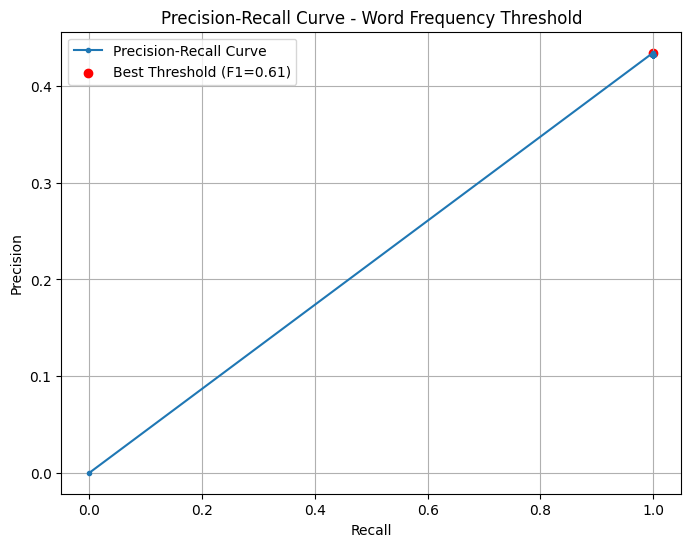

Best frequency threshold: 478553835
Best F1 score: 0.6060
At this threshold - Precision: 0.4347, Recall: 1.0000


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Evaluate Train
precision = get_precision(train_labels, y_pred)
recall = get_recall(train_labels, y_pred)
fscore = get_fscore(train_labels, y_pred)

print("Evaluate Train")
print(f" Precision: {precision:.4f}\n Recall: {recall:.4f}\n F1: {fscore:.4f}\n")

# Evaluate Dev
precision = get_precision(dev_labels, y_pred)
recall = get_recall(dev_labels, y_pred)
fscore = get_fscore(dev_labels, y_pred)

print("Evaluate Dev:")
print(f" Precision: {precision:.4f}\n Recall: {recall:.4f}\n F1: {fscore:.4f}\n\n")

# Plots the Precision-Recall curve for different frequency thresholds:
def plot_precision_recall_curve(train_data, ngram_counts):
    train_words, train_labels = train_data

    # Get frequencies for all training words
    frequencies = [ngram_counts.get(word.lower(), 0) for word in train_words]

    # Initialize lists to store precision and recall values
    precisions = []
    recalls = []
    thresholds = []

    # Generate thresholds from min to max frequency
    min_freq = min(frequencies)
    max_freq = max(frequencies)
    test_thresholds = np.linspace(min_freq, max_freq, 100)
    print(f"Range of thresholds tested: {int(min_freq)} to {int(max_freq)}")

    for threshold in test_thresholds:
        # Make predictions
        y_pred = [1 if freq < threshold else 0 for freq in frequencies]

        # Calculate precision and recall
        precision = get_precision(train_labels, y_pred)
        recall = get_recall(train_labels, y_pred)

        # Store values
        precisions.append(precision)
        recalls.append(recall)
        thresholds.append(threshold)

    # Plot the curve
    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, marker='.', label='Precision-Recall Curve')

    # Find and mark the best threshold (max F1 score)
    f1_scores = [2*p*r/(p+r) if (p+r)>0 else 0 for p,r in zip(precisions, recalls)]
    best_idx = np.argmax(f1_scores)
    plt.scatter(
        recalls[best_idx], precisions[best_idx], color='red',
        label=f'Best Threshold (F1={f1_scores[best_idx]:.2f})')

    plt.title('Precision-Recall Curve - Word Frequency Threshold')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Print the best threshold
    print(f"Best frequency threshold: {thresholds[best_idx]:.0f}")
    print(f"Best F1 score: {f1_scores[best_idx]:.4f}")
    print(f"At this threshold - Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

    return thresholds[best_idx]

# Load data and plot the curve
train_data = load_labeled_file(train_file)
best_threshold = plot_precision_recall_curve(train_data, ngram_counts)

# Section 3. Classifiers

## 3.1 Naive Bayes classification


Now, let’s move on to actual machine learning classifiers! For our first classifier, you will use the built-in [Naive Bayes model from sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html), to train a classifier. You should refer to the online sklearn documentation when you are building your classifier.

The first thing to note is that sklearn classifiers take in `numpy` arrays, rather than regular lists. You may use the [online numpy documentation](https://numpy.org/doc/stable/). To create a `numpy` list of length 5, you can use the following Python commands:

```
import numpy as np
X = np.array([1,2,3,4,5])
```


To train a classifier, you need two numpy arrays: `X_train`, an `m` by `n` array, where `m` is the number of words in the dataset, and `n` is the number of features for each word; and `Y`, an array of length `m` for the labels of each of the words.

**Before we start training models, we need to convert our texts/words into numpy arrays, i.e. making training/testing feature vectors.**

- **Problem 3.0**: Implementing `get_training_features()` and `get_test_features()` that convert train/test dataset to numpy arrays

In [27]:
%%capture
# run the following cell if you want to use count of syllabus as a feature
!pip install syllables
import syllables

In [28]:
import numpy as np

def get_training_features(train_data, ngram_counts):
    words, labels = train_data
    features = []

    for word in words:
        length = len(word)
        frequency = ngram_counts.get(word.lower(), 0)
        features.append([length, frequency])

    X = np.array(features, dtype=np.float64)

    # Compute mean and std for scaling
    means = X.mean(axis=0)
    stds = X.std(axis=0)

    # Avoid divide-by-zero
    stds[stds == 0] = 1.0

    X_scaled = (X - means) / stds
    Y = np.array(labels)

    return X_scaled, Y, means, stds

def get_test_features(words, ngram_counts, means, stds):
    features = []

    for word in words:
        length = len(word)
        frequency = ngram_counts.get(word.lower(), 0)
        features.append([length, frequency])

    X = np.array(features, dtype=np.float64)

    stds[stds == 0] = 1.0
    X_scaled = (X - means) / stds

    return X_scaled


In [ ]:
# PennGrader - DO NOT CHANGE
dev_words, dev_labels = dev_data
X_train, Y_train, means, stds = get_training_features(train_data, ngram_counts)
X_dev = get_test_features(dev_words, ngram_counts, means, stds)

train_feats = (X_train, Y_train, means, stds)
test_feats = (X_dev)

Correct! You earned 3/3 points. You are a star!

Your submission has been successfully recorded in the gradebook.


Once we have these feature arrays, we can fit a Naive Bayes classifier using the following commands:
```
from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
clf.fit(X_train, Y)
```
Finally, to use your model to predict the labels for a set of words, you only need one numpy array: `X_test`, an `m` by `n` array, where `m` is the number of words in the test set, and `n` is the number of features for each word. Note that the `n` used here is the same as the `n` in `X_train`. Then, we can use our classifier to predict labels using the following command:

```
Y_pred = clf.predict(X_test)
```

- **Problem 3.1**: Fill in the function `naive_bayes(train_data, dev_data, ngram_counts)`. This function will train a Naive Bayes classifier on the training data using **word length** and **word frequency** as features, and returns your model’s predictions on the training data and the development data individually.
    - **NOTE**: Before training and testing a classifier, it is generally important to normalize your features. This means that you need to find the mean and standard deviation (sd) of a feature. Then, for each row, perform the following transformation: `X_scaled = (X_original - mean)/sd`. **Be sure to always use the means and standard deviations from the training data**.
    - **Optional**: You can include more features if you want to, e.g. [the count of syllabus](https://github.com/prosegrinder/python-syllables)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

In [31]:
from sklearn.naive_bayes import GaussianNB

def naive_bayes(train_data, dev_words, ngram_counts):
    # Step 1: Extract and scale features
    X_train, Y_train, means, stds = get_training_features(train_data, ngram_counts)
    X_dev = get_test_features(dev_words, ngram_counts, means, stds)

    # Step 2: Train Gaussian Naive Bayes model
    model = GaussianNB()
    model.fit(X_train, Y_train)

    # Step 3: Predict on both train and dev
    train_pred = model.predict(X_train)
    dev_pred = model.predict(X_dev)

    return train_pred.tolist(), dev_pred.tolist()


- **Answer 3.1:** Please report the precision, recall, and f-score on both the training data and the development data.
    - Training **[writeup.pdf]**
    - Development **[writeup.pdf]**

In [32]:
# report train/development metrics!
dev_words, dev_labels = dev_data
train_pred, dev_pred = naive_bayes(train_data, dev_words, ngram_counts)
dev_precision = get_precision(dev_labels, dev_pred)
dev_recall = get_recall(dev_labels, dev_pred)
dev_f = get_fscore(dev_labels, dev_pred)

# Unpack training labels
train_words, train_labels = train_data

# Evaluate training data
train_precision = get_precision(train_labels, train_pred)
train_recall = get_recall(train_labels, train_pred)
train_fscore = get_fscore(train_labels, train_pred)

# Report
print("=== Naive Bayes Metrics ===\n")
print("Training Set:")
print(f"Precision: {train_precision:.4f}")
print(f"Recall:    {train_recall:.4f}")
print(f"F1 Score:  {train_fscore:.4f}\n")

print("Development Set:")
print(f"Precision: {dev_precision:.4f}")
print(f"Recall:    {dev_recall:.4f}")
print(f"F1 Score:  {dev_f:.4f}")

=== Naive Bayes Metrics ===

Training Set:
Precision: 0.4950
Recall:    0.9798
F1 Score:  0.6577

Development Set:
Precision: 0.4693
Recall:    0.9689
F1 Score:  0.6323


## 3.2 Logistic Regression
Next, you will use sklearn’s built-in Logistic Regression classifier. Again, we will use word length and word frequency as your two features. You should refer to [the online sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) when you are building your classifier. To import and use this model, use the following command:

```
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
```

- **Problem 3.2**: For this problem, you will be filling in the function `logistic_regression(train_data, dev_data, ngram_counts)`. This function will train a `Logistic Regression` classifier on the training data, and returns your model’s predictions on the training data and the development data individually.


In [34]:
from sklearn.linear_model import LogisticRegression

def logistic_regression(train_data, dev_words, ngram_counts):
    # Step 1: Extract scaled features
    X_train, Y_train, means, stds = get_training_features(train_data, ngram_counts)
    X_dev = get_test_features(dev_words, ngram_counts, means, stds)

    # Step 2: Train logistic regression model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train, Y_train)

    # Step 3: Predict on both train and dev sets
    train_pred = model.predict(X_train)
    dev_pred = model.predict(X_dev)

    return train_pred.tolist(), dev_pred.tolist()


- **Answer 3.2:** Please report the precision, recall, and f-score on both the training data and the development data.
    - Training **[writeup.pdf]**
    - Development **[writeup.pdf]**

In [35]:
dev_words, dev_labels = dev_data
train_pred, dev_pred = logistic_regression(train_data, dev_words, ngram_counts)
dev_precision = get_precision(dev_labels, dev_pred)
dev_recall = get_recall(dev_labels, dev_pred)
dev_f = get_fscore(dev_labels, dev_pred)
dev_f

# Unpack training labels
train_words, train_labels = train_data

# Evaluate training set
train_precision = get_precision(train_labels, train_pred)
train_recall = get_recall(train_labels, train_pred)
train_fscore = get_fscore(train_labels, train_pred)

# Display results
print("=== Logistic Regression Metrics ===\n")

print("Training Set:")
print(f"Precision: {train_precision:.4f}")
print(f"Recall:    {train_recall:.4f}")
print(f"F1 Score:  {train_fscore:.4f}\n")

print("Development Set:")
print(f"Precision: {dev_precision:.4f}")
print(f"Recall:    {dev_recall:.4f}")
print(f"F1 Score:  {dev_f:.4f}")

=== Logistic Regression Metrics ===

Training Set:
Precision: 0.7250
Recall:    0.6580
F1 Score:  0.6899

Development Set:
Precision: 0.7268
Recall:    0.6938
F1 Score:  0.7099


## 3.3 Comparing Naive Bayes and Logistic Regression
- **Answer 3.3**: After implementing Naive Bayes and Logistic Regression classifiers, you will notice that their performance is not identical, even though they are given the same data. **Write a paragraph below that discusses which model performed better on this task and what are the potential reasons.**
    - [TODO: discussion of the differences in your writeup.pdf]

In [37]:
## Answer in your writeup.pdf

# Section 4. Build your own model
Finally, the fun part! In this section, you will build your own classifier for the complex word identification task, and compare your results to that of your classmates. You will also perform an error analysis for your best performing model.

You can choose any other types of classifier, and any additional features you can think of!
- For classifiers, beyond `Naive Bayes` and `Logistic Regression`, you might consider trying `SVM`, `Decision Trees`, and `Random Forests`, among others.
- Additional word features that you might consider include number of syllables, number of `WordNet` synonyms, and number of `WordNet` senses. To use WordNet in Python, refer to [this documentation](http://www.nltk.org/howto/wordnet.html).
- You could also include sentence-based complexity features, such as length of the sentence, average word length, and average word frequency.

When trying different classifiers, we recommend that you train on training data, and test on the development data, like the previous sections.

In the following cell, please include a description of **all of the models** and **features** that you tried. To receive full credit, you MUST try **at least 1 type of classifier** (not including `Naive Bayes` and `Logistic Regression`), and **at least two features** (not including length and frequency).

**Note**: You can also tune the parameters of your model, e.g. what type of kernel to use. This is NOT required, as some of you may not be that familiar with this.



## 4.1 Your Own Model

An important part of text classification tasks is to determine what your model is getting correct, and what your model is getting wrong. For this problem, you must train your best model on the training data, and report the precision, recall, and f-score on the development data. In order to receive full credit, your model must be able to outperform all of the baselines.

In [38]:
import numpy as np
import re
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def own_model(train_data, dev_words, ngram_counts):
    """
    High-performance classifier with rich engineered features
    """

    def count_syllables(word):
        """Simple syllable estimation via vowel groups"""
        return len(re.findall(r'[aeiouy]+', word.lower()))

    def word_shape_features(word):
        return [
            word[0].isupper(),
            word.isupper(),
            any(char.isdigit() for char in word),
            word.isalpha()
        ]

    def extract_features(words, ngram_counts):
        features = []
        for word in words:
            word_lower = word.lower()
            length = len(word)

            # Avoid log(0)
            freq = ngram_counts.get(word_lower, 1)
            log_freq = np.log(freq)

            syllables = count_syllables(word)

            shape = word_shape_features(word)

            # Morphological suffix score
            suffix_score = sum([
                word_lower.endswith(suffix)
                for suffix in ["tion", "sion", "ous", "ive", "ence", "ance", "ment", "ity", "ize", "ate"]
            ])

            interaction = length * log_freq  # nonlinear feature

            features.append([length, log_freq, syllables, suffix_score, interaction] + shape)

        return np.array(features)

    train_words, train_labels = train_data

    # Build and scale features
    X_train = extract_features(train_words, ngram_counts)
    X_dev = extract_features(dev_words, ngram_counts)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_dev = scaler.transform(X_dev)

    # Stronger Logistic Regression
    clf = LogisticRegression(C=10.0, max_iter=2000)
    clf.fit(X_train, train_labels)

    return clf.predict(X_train), clf.predict(X_dev)



train_data = load_labeled_file("complex_words_training.txt")
dev_data = load_labeled_file("complex_words_development.txt")
ngram_counts = load_ngram_counts("ngram_counts.txt.gz")

dev_words, dev_labels = dev_data
train_pred, dev_pred = own_model(train_data, dev_words, ngram_counts)

print("Precision:", get_precision(dev_labels, dev_pred))
print("Recall:   ", get_recall(dev_labels, dev_pred))
print("F1 Score: ", get_fscore(dev_labels, dev_pred))


Precision: 0.7744360902255639
Recall:    0.7392344497607656
F1 Score:  0.7564259485924113


- **Answer 4.1**: Train your best model on the training data, and report the precision, recall, and f-score on the development data

In [39]:
## Answer in your writeup.pdf

## 4.2 Analyze your model


Describe the model and features you choose, and perform a detailed error analysis of your models. Give several examples of words on which your best model performs well. Also give examples of words which your best model performs poorly on, and identify at least TWO categories of words on which your model is making errors.




- **Answer 4.2**: Write a detailed description of your model and features used. Also include error analysis of your model.

In [40]:
## Answer in your writeup.pdf

## 4.3 Leaderboard
Finally, use your classifier to predict labels for the test data, and submit these labels in a text file named `test_labels.txt` (with one label per line) to the leaderboard; be sure NOT to shuffle the order of the test examples. Instructions for how to post to the leaderboard will be posted on Ed soon.
**In addition, the top 3 submissions will receive 5 bonus points! A successful submission to the leaderboard will guarantee 2 points!**

In [41]:
train_pred, test_pred = own_model(train_data, test_words, ngram_counts)
with open('test_labels.txt', 'w') as f:
    f.write("\n".join(map(str, test_pred)))

- **Results 4.3**: Upload your `test_labels.txt` to the leaderboard in Gradescope.

## 4.4. (Optional) Leaderboard using outside data

While the training data we have provided is sufficient for completing this assignment, it is not the only data for the task of identifying complex words. As an optional addition to this homework, you may look for and use any additional training data, and submit your predicted labels in a text file named `test_labels.txt` to the leaderboard.

As a start, we recommend looking at the [SemEval 2016 dataset](http://alt.qcri.org/semeval2016/task11/), a dataset that was used in a complex words identification competition. In addition, you can try to use data from [Newsela](https://newsela.com/). Newsela’s editors re-write newspaper articles to be appropriate for students at different grade levels. The company has generously shared a dataset with us. The Newsela data **may not** be re-distributed outside of Penn. You can find the data on eniac at `/home1/c/ccb/data/newsela/newsela_article_corpus_with_scripts_2016-01-29.1.zip`.

Good luck, and have fun!